In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Propeller import Propeller
from FastBEMT.DataLoader import load_propeller_dict
from LFProp.Utils import get_oaspl_contour_area
import scienceplots

plt.style.use(['science', 'no-latex'])

In [2]:
# Load propeller geometry
prop_name, blade_dict = load_propeller_dict('APC Dicts/10x7E')[0]

# Define test parameters
n_observers_per_side_range = np.array([8, 12, 16, 20, 24, 28, 32, 36, 40])
grid_size = 5

# Fixed parameters for computation
rpm = 7000
revolutions = 1
num_obs_times_per_rev = 10

print(f'Testing observer grid resolutions: {n_observers_per_side_range}')
print(f'Grid size: {grid_size} m')
print(f'Fixed parameters: rpm={rpm}, revolutions={revolutions}, num_obs_times_per_rev={num_obs_times_per_rev}')

Testing observer grid resolutions: [ 8 12 16 20 24 28 32 36 40]
Grid size: 5 m
Fixed parameters: rpm=7000, revolutions=1, num_obs_times_per_rev=10


In [3]:
# Storage for results
contour_areas = {}  # Dictionary: n_observers_per_side -> contour area (m^2)
num_observers_list = []
area_values = []

print('Running observer grid convergence analysis...')
print()

for n_obs_per_side in n_observers_per_side_range:
    # Create observer grid
    x_range = np.linspace(-grid_size, grid_size, n_obs_per_side)
    y_range = np.linspace(0, grid_size, n_obs_per_side)
    X, Y = np.meshgrid(x_range, y_range)
    Z = np.zeros_like(X)
    r_observers = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)
    
    # Create parameters
    params = LowFidelityParameters(
        rpm=rpm,
        a_inf=343,
        rho=1.225,
        mu=1.81e-5,
        n_blades=blade_dict['n_blades'],
        p_ref=2e-5,
        revolutions=revolutions,
        num_obs_times_per_rev=num_obs_times_per_rev,
        device='cuda',
    )
    
    # Create propeller
    propeller = Propeller(
        geometry=blade_dict,
        params=params,
    )
    
    # Run BEMT
    propeller.run_bemt(v_inf=0.0)
    
    # Run aeroacoustics
    propeller.run_aeroacoustics(
        observer_positions=r_observers,
        lt=0.01,
        i=5e-4,
        alpha_stall=15,
        keep_bpm_components=False
    )
    propeller.postprocess()
    
    # Reshape for contour calculation
    propeller.third_octave_total_oaspl = propeller.third_octave_total_oaspl.reshape(n_obs_per_side, n_obs_per_side)
    propeller.third_octave_total_oaspl = np.vstack([
        propeller.third_octave_total_oaspl[::-1, :],     # Flip for negative y
        propeller.third_octave_total_oaspl[1:, :]        # Original positive y, skip y=0 to avoid duplication
    ])
    
    # Calculate contour area
    area = get_oaspl_contour_area(propeller, target_level=60, size=grid_size, weight_below=1)
    contour_areas[n_obs_per_side] = area
    num_observers_list.append(n_obs_per_side * n_obs_per_side)
    area_values.append(area)
    
    print(f'n_observers_per_side={n_obs_per_side:2d} ({n_obs_per_side*n_obs_per_side:4d} total) -> Contour Area={area:.4f}')

print()
print('Analysis complete.')

Running observer grid convergence analysis...



C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.
[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 776.054 ms
[CUDA TIMING] BPM.__init__: 0.841 ms
[CUDA TIMING] get_observer_times: 122.970 ms
[CUDA TIMING] calculate_f1a_pressure: 243.604 ms
[CUDA TIMING] combine_sources (F1A): 116.611 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 824.188 ms
[CUDA TIMING] BPM.run_forward_bpm: 210.588 ms
[CUDA TIMING] combine_sources_bpm: 3.157 ms
n_observers_per_side= 8 (  64 total) -> Contour Area=38.0091


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.
[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 2.787 ms
[CUDA TIMING] BPM.__init__: 0.875 ms
[CUDA TIMING] get_observer_times: 0.438 ms
[CUDA TIMING] calculate_f1a_pressure: 5.976 ms
[CUDA TIMING] combine_sources (F1A): 1.604 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 3.924 ms
[CUDA TIMING] BPM.run_forward_bpm: 48.355 ms
[CUDA TIMING] combine_sources_bpm: 0.922 ms
n_observers_per_side=12 ( 144 total) -> Contour Area=37.7013


...

[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.
[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 2.255 ms
[CUDA TIMING] BPM.__init__: 0.922 ms
[CUDA TIMING] get_observer_times: 0.333 ms
[CUDA TIMING] calculate_f1a_pressure: 11.375 ms
[CUDA TIMING] combine_sources (F1A): 1.553 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 6.037 ms
[CUDA TIMING] BPM.run_forward_bpm: 110.113 ms
[CUDA TIMING] combine_sources_bpm: 0.244 ms
n_observers_per_side=32 (1024 total) -> Contour Area=37.6225


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.
[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 2.028 ms
[CUDA TIMING] BPM.__init__: 1.640 ms
[CUDA TIMING] get_observer_times: 0.414 ms
[CUDA TIMING] calculate_f1a_pressure: 8.222 ms
[CUDA TIMING] combine_sources (F1A): 1.346 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 4.661 ms
[CUDA TIMING] BPM.run_forward_bpm: 101.666 ms
[CUDA TIMING] combine_sources_bpm: 0.458 ms
n_observers_per_side=36 (1296 total) -> Contour Area=37.6275


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.
[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 1.916 ms
[CUDA TIMING] BPM.__init__: 0.563 ms
[CUDA TIMING] get_observer_times: 0.424 ms
[CUDA TIMING] calculate_f1a_pressure: 10.496 ms
[CUDA TIMING] combine_sources (F1A): 1.876 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 6.295 ms
[CUDA TIMING] BPM.run_forward_bpm: 120.444 ms
[CUDA TIMING] combine_sources_bpm: 0.412 ms
n_observers_per_side=40 (1600 total) -> Contour Area=37.6303

Analysis complete.


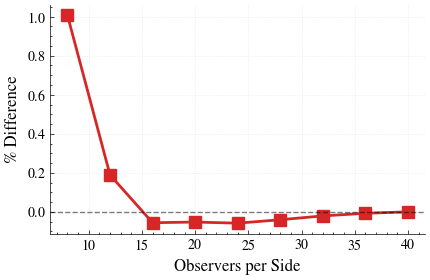

In [4]:
finest_area = area_values[-1]

relative_change = np.array([(area - finest_area) / finest_area * 100 for area in area_values])

fig, ax = plt.subplots(figsize=(4.5, 3))

ax.plot(n_observers_per_side_range, relative_change, 's-', linewidth=2, markersize=8, color='tab:red')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('Observers per Side', fontsize=12)
ax.set_ylabel('% Difference', fontsize=12)
ax.grid(True, alpha=0.3, linestyle=':')

# Remove top and right spines
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(top=False, right=False, which='both')

plt.tight_layout()
plt.savefig('../Figures/Validation/observer_grid_relative_error.png', dpi=200)
plt.show()

In [5]:
# Summary statistics
print('='*60)
print('OBSERVER GRID CONVERGENCE SUMMARY')
print('='*60)
print(f'{"Obs/Side":<12} {"Total Obs":<15} {"Area (m²)":<15} {"Rel. Error (%)":<15}')
print('-'*60)

for i, n_obs_per_side in enumerate(n_observers_per_side_range):
    total_obs = n_obs_per_side * n_obs_per_side
    area = area_values[i]
    rel_error = relative_change[i]
    print(f'{n_obs_per_side:<12d} {total_obs:<15d} {area:<15.6f} {rel_error:<15.4f}')

print('-'*60)
print(f'Convergence achieved: {"Yes" if np.abs(relative_change[-1]) < 1.0 else "No"} (within 1% of finest grid)')

OBSERVER GRID CONVERGENCE SUMMARY
Obs/Side     Total Obs       Area (m²)       Rel. Error (%) 
------------------------------------------------------------
8            64              38.009134       1.0067         
12           144             37.701326       0.1887         
16           256             37.609296       -0.0558        
20           400             37.610582       -0.0524        
24           576             37.608451       -0.0581        
28           784             37.615035       -0.0406        
32           1024            37.622467       -0.0208        
36           1296            37.627492       -0.0075        
40           1600            37.630307       0.0000         
------------------------------------------------------------
Convergence achieved: Yes (within 1% of finest grid)
